In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import pickle

#### Lectura de train y test

In [2]:
df = pd.read_csv(r'C:\Users\plaza\Desktop\Documentos_Clase\ONLINE_DS_THEBRIDGE_Alejandro_Plaza\Proyecto_ML\data\processed\dfdefinitivo.csv')
df.head()

,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,PI_High,PI_Low,AtR_High,AtR_Low,Exam_Score
0,0,4,7,1,0,0,0,1,9
1,1,27,13,0,0,1,0,0,3
2,1,25,6,1,1,0,0,0,9
3,1,13,11,1,0,0,0,0,2
4,2,23,1,1,0,1,1,0,7


#### Dividimos en train y test

In [3]:
X = df.drop(columns = 'Exam_Score')
y = df['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 30)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 8)
(2000, 8)
(8000,)
(2000,)


### Entrenamos al modelo

In [5]:
lm = LinearRegression()

In [6]:
lm.fit(X_train, y_train)

LinearRegression()

#### Comprobamos qué tal lo hace con el test

<Axes: xlabel='Exam_Score'>

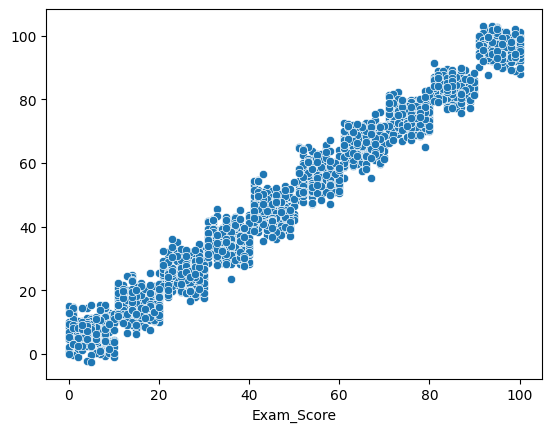

In [7]:
predictions = lm.predict(X_test)
sns.scatterplot(x = y_test, y = predictions)

In [8]:
lm.score(X_test, y_test)

0.9705117599867098

In [9]:
print('MAE:', mean_absolute_error(y_test, predictions))
print('MSE:', mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(mean_squared_error(y_test, predictions)))

MAE: 4.035224815108551
MSE: 24.470107306272777
RMSE: 4.946726928613786


Hacemos una breve prueba a ver como actúa ante nuevos datos, y vemos que se ajusta bastante bien

In [ ]:
lm.predict([[0, 0, 73, 3, 1, 0, 0, 0]])

c:\Users\plaza\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([38.38970193])

In [13]:
lm.predict([[0, 100, 0, 3, 1, 0, 0, 0]])

c:\Users\plaza\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([26.1532194])

In [14]:
lm.predict([[20, 0, 0, 3, 1, 0, 0, 0]])

c:\Users\plaza\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([14.08384369])

### Guardamos el modelo

In [12]:
with open(r"C:\Users\plaza\Desktop\Documentos_Clase\ONLINE_DS_THEBRIDGE_Alejandro_Plaza\Proyecto_ML\models\linear_reg.pkl", "wb") as f:
    pickle.dump(lm, f)